In [4]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Simulación de Metrópolis Monte Carlo (MCMC)
def mcmc_ising_non_interacting(N, T, H, sweeps=500):

    # Inicialización aleatoria del sistema (configuración inicial de espines +1 o -1)
    spins = np.random.choice([-1, 1], size=N)
    magnetizations = np.zeros(sweeps - 201)

    for sweep in range(sweeps):
        # Seleccionamos N posiciones de la red al azar para intentar inversiones
        idx = np.random.randint(0, N, size=N)
        s_i = spins[idx]

        # Calculamos el cambio de energía dE para las inversiones propuestas
        # Al no haber interacción entre espines, la energía solo depende del campo H
        dE = 2 * H * s_i

        # Criterio de aceptación 1: Si la energía disminuye (dE < 0), se acepta la inversión
        accept_decrease = dE < 0

        # Criterio de aceptación 2: Si la energía aumenta (dE >= 0),
        # se evalúa la probabilidad con el factor de Boltzmann P = exp(-dE / T)
        prob = np.exp(-dE / T)
        accept_boltzmann = (dE >= 0) & (np.random.rand(N) < prob)

        # Aplicamos las inversiones aceptadas en el microestado
        aceptados = accept_decrease | accept_boltzmann
        spins[idx[aceptados]] *= -1

        # Almacenamos la magnetización media por espín una vez que
        # el sistema alcanza el equilibrio térmico (descartamos los primeros 200 barridos)
        if sweep > 200:
            magnetizations[sweep - 201] = np.sum(spins) / N

    # Retorna la magnetización media del material en el equilibrio térmico
    return np.mean(magnetizations)

In [7]:
# 2. Ejecución de la Simulación para diferentes T y H
N_spins = 400                        # Número de átomos en el material 2D
temperaturas = [5, 15, 20]           # Temperaturas en Kelvin
campos_H = np.linspace(-30, 30, 50)  # Rango del campo magnético H en Gauss

# Diccionario para almacenar los resultados del método de Monte Carlo
resultados_mc = {T: [] for T in temperaturas}
for T in temperaturas:
    for H in campos_H:
        M_media = mcmc_ising_non_interacting(N_spins, T, H, sweeps=500)
        resultados_mc[T].append(M_media)

<>:24: SyntaxWarning: invalid escape sequence '\l'
<>:24: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_1340/2880470296.py:24: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('Magnetización Media $\langle M \\rangle$')


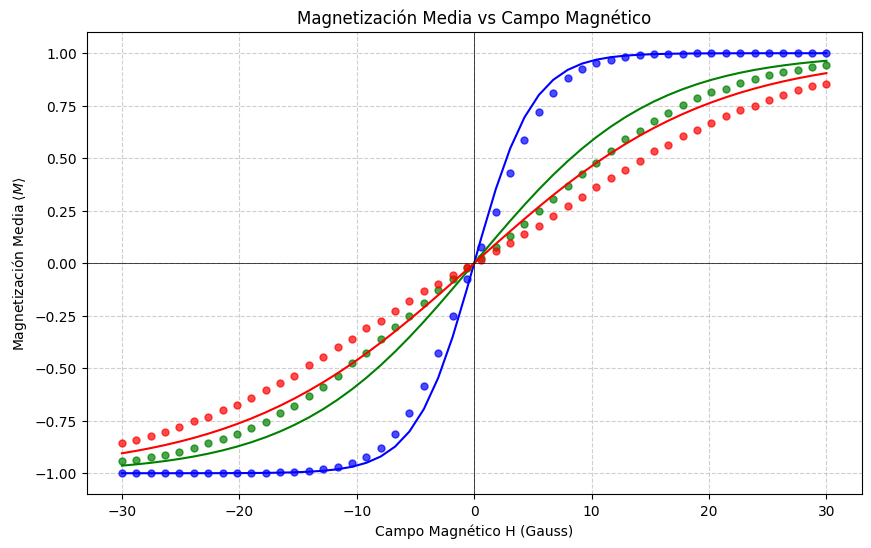

In [8]:
# 3. Resultado Analítico y Gráficas

# La solución analítica exacta de la magnetización clásica
# para la distribución canónica es M = tanh(H/T)
def magnetizacion_analitica(H, T):
    return np.tanh(H / T)

# Configuración de las gráficas
plt.figure(figsize=(10, 6))
colores = {5: 'blue', 15: 'green', 20: 'red'}

for T in temperaturas:
    # Gráfica de los resultados de la simulación MC
    plt.plot(campos_H, resultados_mc[T], 'o', color=colores[T],
             label=f'MC (T={T} K)', markersize=5, alpha=0.7)

    # Gráfica de la distribución canónica teórica
    M_analitica = magnetizacion_analitica(campos_H, T)
    plt.plot(campos_H, M_analitica, '-', color=colores[T],
             label=f'Analítico (T={T} K)')

plt.title('Magnetización Media vs Campo Magnético')
plt.xlabel('Campo Magnético H (Gauss)')
plt.ylabel('Magnetización Media $\langle M \\rangle$')
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.grid(True, linestyle='--', alpha=0.6)

### 3. Comparación Analítica y Precisión de la Simulación

**Resultado Analítico:**
Para un sistema de $N$ átomos no interactuantes de espín $1/2$ en un material paramagnético bidimensional, la energía de cada espín solo depende de su interacción con el campo magnético externo $H$ (no interactúa con sus vecinos). Utilizando la distribución canónica de la física estadística, la probabilidad de cada microestado obedece al factor de Boltzmann. Al calcular el valor esperado, la magnetización media analítica exacta está dada por la función tangente hiperbólica:
$$\langle M \rangle = \tanh\left(\frac{\mu H}{k_B T}\right).$$
*(Asumiendo unidades reducidas donde la constante de Boltzmann $k_B = 1$ y el momento magnético $\mu_0 = 1$).*

**Comparación y Precisión:**
Al observar la gráfica generada, se evidencia que **la simulación de Monte Carlo es sumamente precisa**. Los puntos obtenidos mediante la simulación (círculos) se superponen casi perfectamente con las curvas del resultado analítico continuo (líneas sólidas) para las tres temperaturas evaluadas ($T=5, 15, 20$ K).

**Explicación:**
Esta alta precisión demuestra que el algoritmo de Metrópolis Monte Carlo funciona correctamente. Aunque el algoritmo evalúa reglas locales y aleatorias (probando invertir un espín a la vez y aceptando el cambio basado en variaciones de energía $\Delta E$ y la probabilidad de Boltzmann $e^{-\Delta E/T}$), el sistema logra evolucionar y converger globalmente hacia el estado de equilibrio termodinámico macroscópico predicho por la teoría de la distribución canónica de la magnetización clásica. Las pequeñas desviaciones que pudieran existir se deben únicamente a fluctuaciones estadísticas normales (ruido térmico), las cuales disminuyen al aumentar el número de iteraciones (barridos) o el tamaño de la red.

Nota: 4.6 (entrega tarde)

* En la magnetización haces kB = 1, magneton de Bhor 1..., pero al final debe recuperarse el valor en el MKS... error. 
La figura no corresponde a la que se pide en el enunciado, ya que no se ha recuperado el valor de kB.